In [1]:
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import chi2
from datetime import datetime, timedelta
from typing import *

import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np


ROOT_DIR = Path(os.getcwd()).parent

<h4>Rewriting the code using more efficient Polars</h4>

In [49]:
@dataclass
class PumpEvent:
    ticker: str
    pump_time: str

    def __post_init__(self):
        self.pump_time = datetime.strptime(self.pump_time, "%Y-%m-%d %H:%M:%S")

pump = PumpEvent(ticker="GXSBTC", pump_time="2022-05-02 17:00:07")

In [50]:
def create_date_range(start: datetime, end: datetime) -> List[str]:
    """Creates a range of months and years between two dates"""
    start_year = start.year
    start_month = start.month
    end_year = end.year
    end_month = end.month

    date_range = []

    for year in range(start_year, end_year + 1):
        start_month_range = start_month if year == start_year else 1
        end_month_range = end_month if year == end_year else 12

        for month in range(start_month_range, end_month_range + 1):
            date_range.append(datetime(year=year, month=month, day=1))

    return date_range

In [51]:
def load_data(pump_event: PumpEvent, lookback_delta: timedelta) -> pl.DataFrame:
    rb = pump_event.pump_time
    lb = rb - lookback_delta

    ts_range = create_date_range(start=lb, end=rb)

    TICKER_DIR = os.path.join(ROOT_DIR, "data/trades", pump_event.ticker)
    df = pl.DataFrame()

    for date in ts_range:
        month, year = str(date.month).zfill(2), date.year
        slug = f"{pump_event.ticker}-{year}-{str(month).zfill(2)}.parquet"
        df_tmp = pl.read_parquet(os.path.join(TICKER_DIR, slug))

        df = df.vstack(df_tmp)

    return df

In [53]:
df = load_data(pump_event=pump, lookback_delta=timedelta(days=60))
df.head()

In [38]:
df = df.with_columns(
    ((1 - 2 * pl.col("isBuyerMaker").cast(pl.Int8)) * pl.col("qty")).alias("qty_sign")
)
df.head()

trade_id,price,qty,time,isBuyerMaker,qty_sign
i64,f64,f64,datetime[ns],bool,f64
213764,0.000001,115.0,2022-03-01 00:00:30.376,true,-115.0
213765,0.000001,118.0,2022-03-01 00:00:31.378,true,-118.0
213766,0.000001,117.0,2022-03-01 00:00:31.393,true,-117.0
213767,0.000001,116.0,2022-03-01 00:00:31.399,true,-116.0
213768,0.000001,117.0,2022-03-01 00:00:31.415,true,-117.0


In [39]:
df_group = df.group_by("time", maintain_order=True).agg(
    # Price aggregation
    price_first=pl.col("price").first(),
    price_last=pl.col("price").last(),
    price_min=pl.col("price").min(),
    price_max=pl.col("price").max(),
    price_mean=pl.col("price").mean(),
    # isBuyerMaker Aggregation
    isBuyerMaker=pl.col("isBuyerMaker").mean(),
    qty_abs=pl.col("qty").sum(),
    qty_sign=pl.col("qty_sign").sum(),
)

df_group = df_group.with_columns(
    time=pl.col("time").set_sorted()
)

df_group.shape

(64312, 9)

In [40]:
df_group["isBuyerMaker"].value_counts().sort(by="isBuyerMaker")

isBuyerMaker,count
f64,u32
0.0,33563
0.0625,1
0.071429,1
0.133333,1
0.166667,1
0.25,2
0.333333,6
0.384615,1
0.4,1


In [41]:
df_group["time"].max(), df_group["time"].min()

(datetime.datetime(2022, 5, 31, 23, 33, 26, 496000),
 datetime.datetime(2022, 3, 1, 0, 0, 30, 376000))

<h4>Whale features</h4>

<h4>Whale Imbalance</h4>

In [42]:
window = "7d"

df_group = df_group.with_columns(
    is_whale = pl.col("qty_abs") >= pl.col("qty_abs").rolling_quantile(
        quantile=0.999, by="time", window_size=window
    ),
    is_buy = pl.col("qty_sign") > 0
)

df_group.head(10)

time,price_first,price_last,price_min,price_max,price_mean,isBuyerMaker,qty_abs,qty_sign,is_whale,is_buy
datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
2022-03-01 00:00:30.376,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,115.0,-115.0,true,false
2022-03-01 00:00:31.378,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,118.0,-118.0,true,false
2022-03-01 00:00:31.393,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,117.0,-117.0,false,false
2022-03-01 00:00:31.399,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,116.0,-116.0,false,false
2022-03-01 00:00:31.415,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,117.0,-117.0,false,false
2022-03-01 00:02:10.496,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,8130.0,-8130.0,true,false
2022-03-01 00:02:11.779,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,5769.0,-5769.0,false,false
2022-03-01 00:02:17.047,0.000001,0.000001,0.000001,0.000001,0.000001,0.0,6425.0,6425.0,false,true
2022-03-01 00:02:17.055,0.000001,0.000001,0.000001,0.000001,0.000001,0.0,8069.0,8069.0,false,true


In [43]:
df_group = df_group.with_columns(
    whale_imbalance_ratio=(
        (pl.col("qty_sign") * pl.col("is_whale")).rolling_sum(
            by="time", window_size=window
        )
        / (pl.col("qty_abs") * pl.col("is_whale")).rolling_sum(
            by="time", window_size=window
        )
    ),
    regular_imbalance_ratio=(
        (pl.col("qty_sign") * (1 - pl.col("is_whale"))).rolling_sum(
            by="time", window_size=window
        )
        / (pl.col("qty_abs") * (1 - pl.col("is_whale"))).rolling_sum(
            by="time", window_size=window
        )
    ),
)

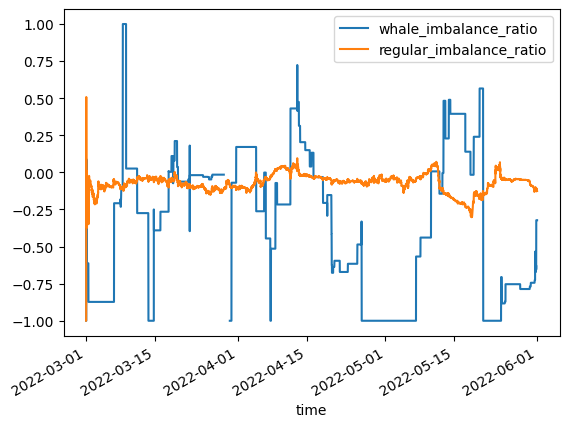

In [44]:
df_group.to_pandas().plot(x="time", y=["whale_imbalance_ratio", "regular_imbalance_ratio"])
plt.show()

<h4>When do whales buy?</h4>

<h4>

In [45]:
df_group = df_group.with_columns(
    weekday = pl.col("time").dt.weekday()
)

df_group.head(1)

time,price_first,price_last,price_min,price_max,price_mean,isBuyerMaker,qty_abs,qty_sign,is_whale,is_buy,whale_imbalance_ratio,regular_imbalance_ratio,weekday
datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,f64,f64,i8
2022-03-01 00:00:30.376,0.000001,0.000001,0.000001,0.000001,0.000001,1.0,115.0,-115.0,true,false,-1.0,NaN,2


In [46]:
# prepend dummies dataframe to the right
weekday_dummmies = df_group["weekday"].to_dummies()
weekday_cols = weekday_dummmies.columns

df_group = df_group.with_columns_seq(weekday_dummmies)

df_group = df_group.with_columns(
    whale_vol=(pl.col("is_whale") * pl.col("qty_abs")).rolling_sum(
        by="time", window_size=window
    ),
    whale_num_trade=pl.col("is_whale").cast(pl.Float32).rolling_sum(by="time", window_size=window),
)

df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg([
        # weekday_dummy * is_whale * qty_abs
        (pl.col(col) * pl.col("is_whale") * pl.col("qty_abs")).sum()
        for col in weekday_cols
    ])
)

In [47]:
df_group = df_group.with_columns_seq(
    [pl.col(f"weekday_{i}") / pl.col("whale_vol") for i in range(1, 8)]
)

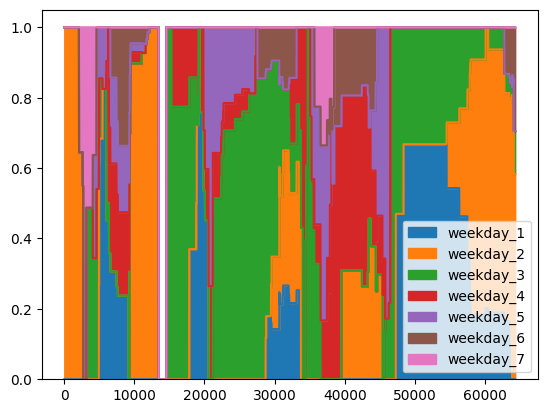

In [48]:
df_group.to_pandas()[weekday_cols].round(6).plot.area()
plt.show()

<h4>Trading volume by hours</h4>

In [18]:
df_group = df_group.with_columns(
    hour=pl.col("time").dt.hour()
)
# Bins hours
bin_hours = [3, 6, 9, 12, 15, 18, 21]
labels=["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]
# Create bins for hours
df_group = df_group.with_columns(
    hour_bin = pl.col("hour").cut(breaks=bin_hours, labels=labels, left_closed=True)
)

In [19]:
# Create dummies for hour bin of the trades
hour_bins_dummies = df_group["hour_bin"].to_dummies()
hour_bins_cols = hour_bins_dummies.columns

df_group = df_group.with_columns_seq(
    hour_bins_dummies
)

# calculate hour bin whale volume
df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg(
        [
            # hour_bin_dummy * is_whale * qty_abs
            (pl.col(col) * pl.col("is_whale") * pl.col("qty_abs")).sum()
            for col in hour_bins_cols
        ]
    )
)

# divide by the overall traded volume
df_group = df_group.with_columns_seq(
    [pl.col(col) / pl.col("whale_vol") for col in hour_bins_cols]
)

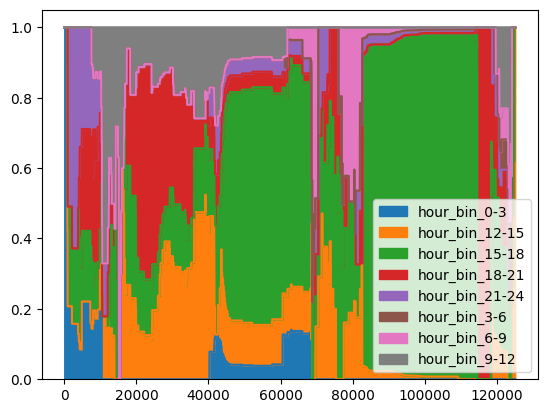

In [20]:
df_group[hour_bins_cols].to_pandas().round(6).plot.area()
plt.show()

<h4>Calculate Benford's law chi squared stat</h4>

<Axes: >

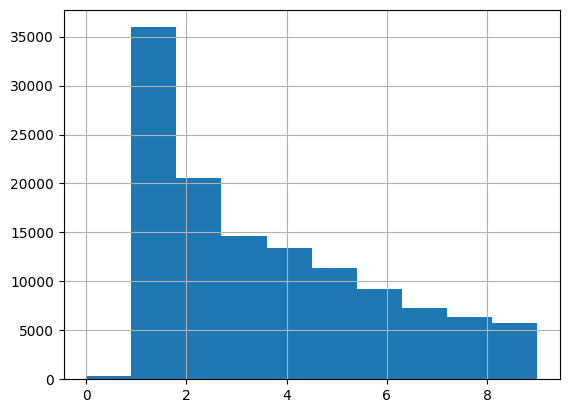

In [21]:
df_group = df_group.with_columns(
    qty_first_digit = pl.col("qty_abs").cast(str).str.slice(0,1).cast(pl.Int8)
)

# Similarily create dummies for each first digit
df_group["qty_first_digit"].to_pandas().hist(bins=10)

In [22]:
df_group = df_group.filter(
    pl.col("qty_first_digit") > 0
)

In [23]:
first_digits_dummies = df_group["qty_first_digit"].to_dummies()
first_digit_cols = first_digits_dummies.columns

df_group = df_group.with_columns_seq(first_digits_dummies)

df_group = df_group.with_columns_seq(
    df_group.rolling(index_column="time", period=window).agg(
        [
            # hour_bin_dummy * is_whale * qty_abs
            (pl.col(col) * pl.col("is_whale")).sum()
            for col in first_digit_cols
        ]
    )
)

In [24]:
df_group.filter(pl.col("is_whale"))[["qty_first_digit"] + first_digit_cols].head(10)

qty_first_digit,qty_first_digit_1,qty_first_digit_2,qty_first_digit_3,qty_first_digit_4,qty_first_digit_5,qty_first_digit_6,qty_first_digit_7,qty_first_digit_8,qty_first_digit_9
i8,i64,i64,i64,i64,i64,i64,i64,i64,i64
1,1,0,0,0,0,0,0,0,0
3,1,0,1,0,0,0,0,0,0
6,1,0,1,0,0,1,0,0,0
3,1,0,2,0,0,1,0,0,0
5,1,0,2,0,1,1,0,0,0
7,1,0,2,0,1,1,1,0,0
8,1,0,2,0,1,1,1,1,0
1,2,0,2,0,1,1,1,1,0
2,2,1,2,0,1,1,1,1,0


In [25]:
# logarithmic distribution Benford's law
expected_freq = pl.Series([np.log(i + 1) - np.log(i) for i in range(1, 10)])
expected_freq

""
f64
0.693147
0.405465
0.287682
0.223144
0.182322
0.154151
0.133531
0.117783
0.105361


In [26]:
from scipy.stats import chi2

In [27]:
# add expected frequencies
df_group = df_group.with_columns(*[
    # expected frequency = distrib * whale_num_trades so far
    (expected_freq[i] * pl.col("whale_num_trade")).alias(f"expected_freq_digit_{i+1}") 
    for i, col in enumerate(first_digit_cols)
])

expected_freq_cols = [
    f"expected_freq_digit_{i}" for i in range(1, 10)
]

# calculate chi_squared statistic
df_group = df_group.with_columns(
    chi2_stat = (
        (df_group[first_digit_cols] - df_group[expected_freq_cols]) / df_group[expected_freq_cols]
    ).sum_horizontal().pow(2)
)

In [28]:
features = [
    "time", "whale_imbalance_ratio", "regular_imbalance_ratio", "chi2_stat"
] + hour_bins_cols + weekday_cols

df_features = df_group[features]
df_features.head(2)

time,whale_imbalance_ratio,regular_imbalance_ratio,chi2_stat,hour_bin_0-3,hour_bin_12-15,hour_bin_15-18,hour_bin_18-21,hour_bin_21-24,hour_bin_3-6,hour_bin_6-9,hour_bin_9-12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_7
datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2021-11-01 00:02:15.476,-1.0,NaN,57.112858,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-11-01 00:05:04.956,0.252446,NaN,42.779747,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


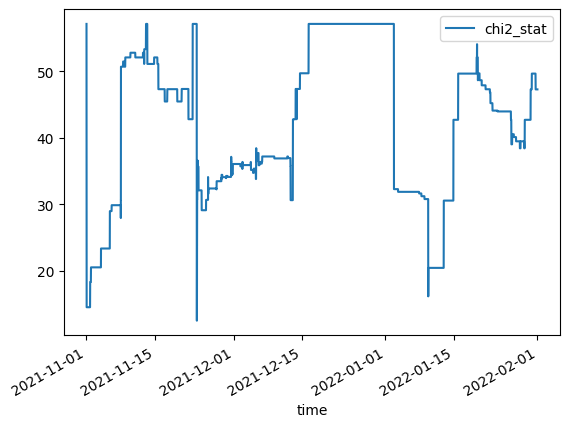

In [29]:
df_group[["time", "chi2_stat"]].to_pandas().plot(x="time", y="chi2_stat")
plt.show()

<Axes: >

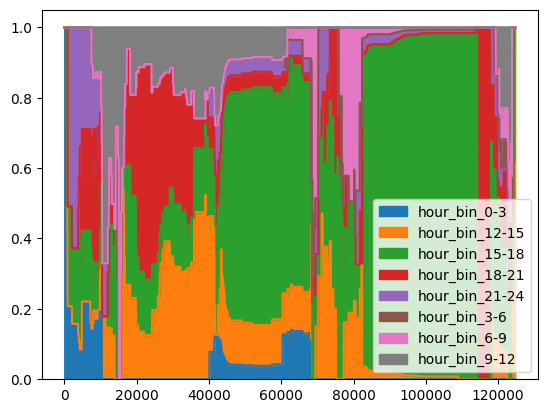

In [30]:
df_features.to_pandas()[hour_bins_cols].round(6).plot.area()

In [31]:
df_features = df_features.rolling(index_column="time", period="1d").agg(
    whale_imbalance_ratio_mean=pl.col("whale_imbalance_ratio").mean(),
    regular_imbalance_ratio_mean=pl.col("regular_imbalance_ratio").mean(),
    # Weekday cols, median - max
    * [pl.col(col).median().alias(f"{col}_median") for col in weekday_cols],
    *[pl.col(col).max().alias(f"{col}_max") for col in weekday_cols],
    # Hours cols, median - max,
    *[pl.col(col).median().alias(f"{col}_median") for col in hour_bins_cols],
    *[pl.col(col).max().alias(f"{col}_max") for col in hour_bins_cols],
    # Pvalue
    *[
        pl.col("chi2_stat").median().alias("chi2_stat_median"),
        pl.col("chi2_stat").max().alias("chi2_stat_max"),
    ],
)

In [32]:
# select 24*14 hours before

df_res = pl.DataFrame()

for i in range(1, 24*14 + 1):
    after_threshold = df_features["time"] >= pump.pump_time - timedelta(minutes=15) - timedelta(hours=i)

    df_res = pl.concat([
        df_res, df_features.filter(after_threshold)[0]
    ])

df_res = df_res.to_pandas()

In [33]:
df_res.index = [f"H_{i}" for i in range(1, 24*14+1)]
df_res = df_res.unstack().to_frame().sort_index(level=1).T
df_res.columns = df_res.columns.map("_".join)
df_res

,chi2_stat_max_H_1,chi2_stat_median_H_1,hour_bin_0-3_max_H_1,hour_bin_0-3_median_H_1,hour_bin_12-15_max_H_1,hour_bin_12-15_median_H_1,hour_bin_15-18_max_H_1,hour_bin_15-18_median_H_1,hour_bin_18-21_max_H_1,hour_bin_18-21_median_H_1,...,weekday_3_median_H_99,weekday_4_max_H_99,weekday_4_median_H_99,weekday_5_max_H_99,weekday_5_median_H_99,weekday_6_max_H_99,weekday_6_median_H_99,weekday_7_max_H_99,weekday_7_median_H_99,whale_imbalance_ratio_mean_H_99
0,57.112858,57.112858,0.0,0.0,0.329588,0.175025,0.222102,0.151621,-0.0,-0.0,...,0.147782,-0.0,-0.0,0.0,0.0,0.258814,0.258814,0.432126,0.432126,0.46269
